# Pancreatic Cancer Detection Using Clinical Biomarkers

The objective of this project is to investigate whether machine learning techniques can help identify pancreatic cancer using clinical biomarker measurements.
Through exploratory analysis, feature engineering, predictive modeling and explainable artificial intelligence methods, the project aims to determine which biomarkers contribute most strongly to pancreatic cancer detection.
Early identification of pancreatic cancer is particularly important due to the disease's high mortality rate and the challenges associated with detecting it at an early stage.


## Data Loading

The pancreatic cancer dataset is loaded and prepared for exploratory analysis.
The dataset contains demographic information, clinical measurements and biomarker values associated with pancreatic cancer diagnosis and staging.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/pancreatic_600_risk123.csv")

df.head()

,sample_id,patient_cc,sample_o,age,sex,diagnosis,stage,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
0,S00111,Cohort1,CPTB,50,M,1,1,8.4501,0.5702,0.1307,79.1530,62.4789,602.2779,248.9139,0.5865,1.2925,108.63,98.4,5.61
1,S00420,Cohort2,BPTB,37,M,3,3,21.4297,0.8658,1.0011,257.8259,165.6953,690.4149,426.4674,8.6544,2.8729,102.61,118.0,6.34
2,S00566,Cohort2,CPTB,80,M,2,2,12.5803,0.8598,2.0098,71.1271,37.2556,721.6129,66.9918,7.6914,1.3359,72.08,7.4,6.14
3,S00078,Cohort1,BPTB,81,M,2,2,10.7277,1.1186,1.0485,114.6138,190.6209,725.6884,177.5647,4.3099,0.4216,120.19,98.8,5.46
4,S00182,Cohort1,BPTB,70,M,2,2,6.1396,1.2448,1.4906,268.5535,173.6363,713.5417,27.8392,4.6962,2.7625,91.05,84.7,6.83


## Dataset Overview

An initial assessment of the dataset is performed to understand its structure, identify missing values and inspect the available variables.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sample_id     600 non-null    str    
 1   patient_cc    600 non-null    str    
 2   sample_o      600 non-null    str    
 3   age           600 non-null    int64  
 4   sex           600 non-null    str    
 5   diagnosis     600 non-null    int64  
 6   stage         600 non-null    int64  
 7   plasma_C      600 non-null    float64
 8   creatinine    600 non-null    float64
 9   LYVE1         600 non-null    float64
 10  REG1B         600 non-null    float64
 11  TFF1          600 non-null    float64
 12  REG1A         600 non-null    float64
 13  CA19_9        600 non-null    float64
 14  CEA           600 non-null    float64
 15  bilirubin     600 non-null    float64
 16  glucose       600 non-null    float64
 17  urine_volume  600 non-null    float64
 18  urine_pH      600 non-null    float64
dty

In [8]:
df.describe()

,age,diagnosis,stage,plasma_C,creatinine,LYVE1,REG1B,TFF1,REG1A,CA19_9,CEA,bilirubin,glucose,urine_volume,urine_pH
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,57.028333,1.790000,1.790000,13.110681,1.051478,0.923620,127.968612,148.338573,678.683848,193.808119,4.104647,1.434683,100.070117,78.693167,6.197150
std,16.123403,0.774748,0.774748,5.936106,0.285160,0.523753,71.701619,91.656459,69.879088,150.798899,2.616863,0.890864,18.650696,29.567852,0.996623
min,30.000000,1.000000,1.000000,0.295000,0.090100,0.014300,0.386200,1.326800,504.633800,0.208800,0.002100,0.000300,38.640000,2.700000,4.500000
25%,43.000000,1.000000,1.000000,9.064550,0.853850,0.505550,75.175825,77.443200,624.786475,76.629775,1.990400,0.729750,88.172500,57.950000,5.397500
50%,57.000000,2.000000,2.000000,12.447000,1.051850,0.867700,119.184100,139.879300,679.020050,153.849550,3.819500,1.325300,99.765000,78.550000,6.140000
75%,71.250000,2.000000,2.000000,16.959100,1.243300,1.281850,185.633875,205.363825,731.210700,295.639325,5.846650,2.061825,112.732500,98.650000,7.072500
max,85.000000,3.000000,3.000000,33.042000,1.785700,2.600300,325.617300,437.267100,869.094400,770.601100,12.921700,3.988900,155.680000,171.600000,7.990000


In [9]:
df.isnull().sum()

sample_id       0
patient_cc      0
sample_o        0
age             0
sex             0
diagnosis       0
stage           0
plasma_C        0
creatinine      0
LYVE1           0
REG1B           0
TFF1            0
REG1A           0
CA19_9          0
CEA             0
bilirubin       0
glucose         0
urine_volume    0
urine_pH        0
dtype: int64

## Target Variable Exploration

The distribution of the diagnosis variable is examined to understand the balance between healthy individuals, benign conditions and pancreatic cancer cases.

In [3]:
df["diagnosis"].value_counts()

diagnosis
1    256
2    214
3    130
Name: count, dtype: int64

In [4]:
(
    df["diagnosis"]
    .value_counts(normalize=True)
    .round(3) * 100
)

diagnosis
1    42.7
2    35.7
3    21.7
Name: proportion, dtype: float64

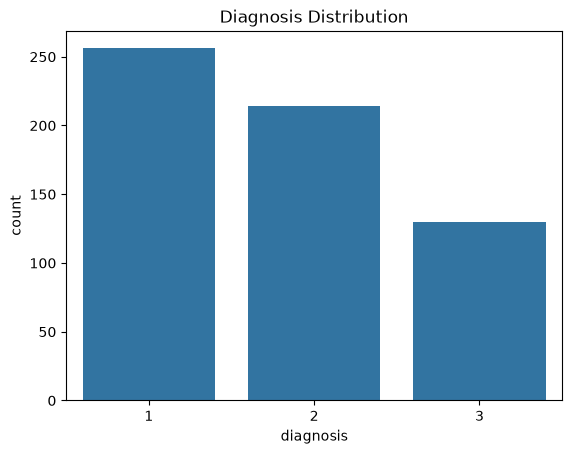

In [5]:
sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Diagnosis Distribution")

plt.show()

### Findings

The dataset contains 600 patient records and 19 variables, including demographic information, diagnostic labels, cancer staging information and multiple clinical biomarkers.
No missing values were detected across any variable, eliminating the need for missing-value imputation.
The target variable (diagnosis) is reasonably balanced, with:

- Healthy: 42.7%
- Benign condition: 35.7%
- Pancreatic cancer: 21.7%

This distribution is considerably more balanced than many medical datasets and should support reliable multiclass classification modelling.

## Diagnosis Mapping

The diagnosis categories are converted into descriptive labels to improve interpretability throughout the analysis.

In [6]:
diagnosis_map = {
    1: "Healthy",
    2: "Benign",
    3: "Pancreatic Cancer"
}

df["diagnosis_label"] = (
    df["diagnosis"]
    .map(diagnosis_map)
)

df[
    [
        "diagnosis",
        "diagnosis_label"
    ]
].drop_duplicates()

,diagnosis,diagnosis_label
0,1,Healthy
1,3,Pancreatic Cancer
2,2,Benign


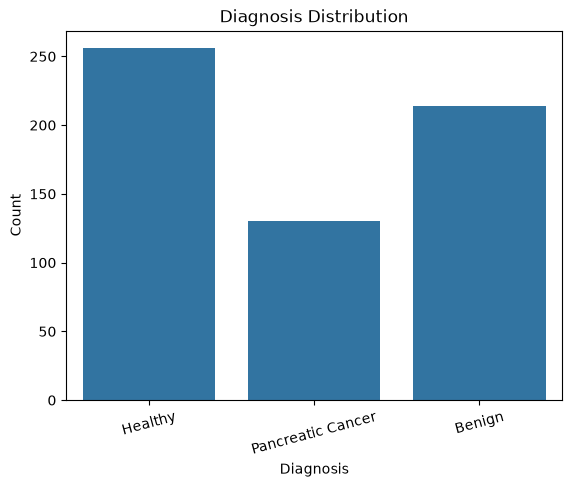

In [15]:
sns.countplot(
    data=df,
    x="diagnosis_label"
)

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

## Univariate Biomarker Analysis

The distribution of key biomarkers is examined across the three diagnosis categories.
This analysis helps identify variables that may have predictive value for pancreatic cancer detection.

### CA19-9 Distribution by Diagnosis

CA19-9 is one of the most commonly used biomarkers in pancreatic cancer diagnosis.
Its relationship with diagnosis categories is explored as a first indicator of predictive potential.

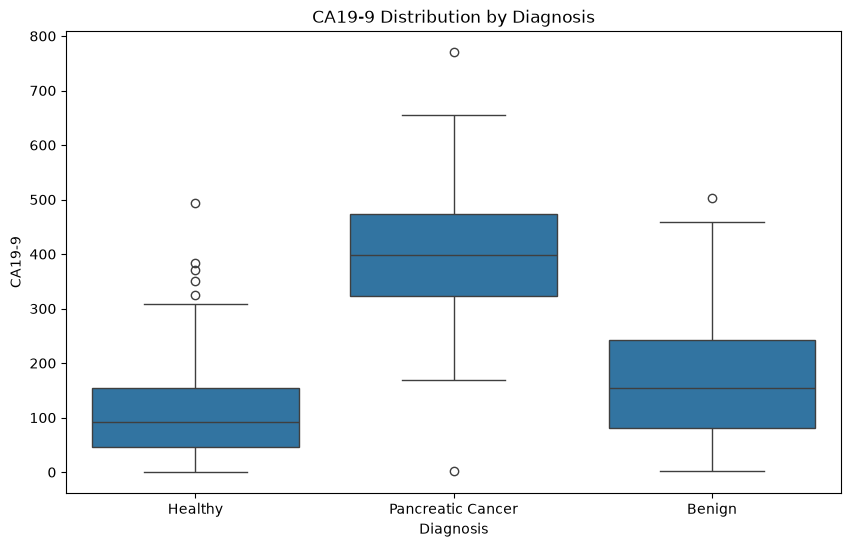

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="diagnosis_label",
    y="CA19_9"
)

plt.title("CA19-9 Distribution by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("CA19-9")

plt.show()

In [17]:
df.groupby("diagnosis_label")["CA19_9"].describe()

,count,mean,std,min,25%,50%,75%,max
diagnosis_label,,,,,,,,
Benign,214.0,166.550528,108.265008,1.2520,80.789175,154.45195,242.991175,502.1000
Healthy,256.0,110.116177,83.020788,0.2088,46.063450,92.05850,153.550225,492.9307
Pancreatic Cancer,130.0,403.487055,114.784541,1.6206,322.605775,398.17295,473.077050,770.6011


### Findings

CA19-9 exhibits substantial differences between diagnosis groups.
Patients diagnosed with pancreatic cancer show considerably higher CA19-9 values, with a median close to 400, compared to approximately 154 for benign conditions and 92 for healthy individuals.
Although some overlap exists between groups, the pancreatic cancer cohort is clearly shifted towards higher CA19-9 values, suggesting strong predictive potential.

### CEA Distribution by Diagnosis

CEA is another clinically relevant biomarker commonly used in cancer assessment.
Its distribution across diagnosis groups is examined to evaluate its potential contribution to pancreatic cancer detection.

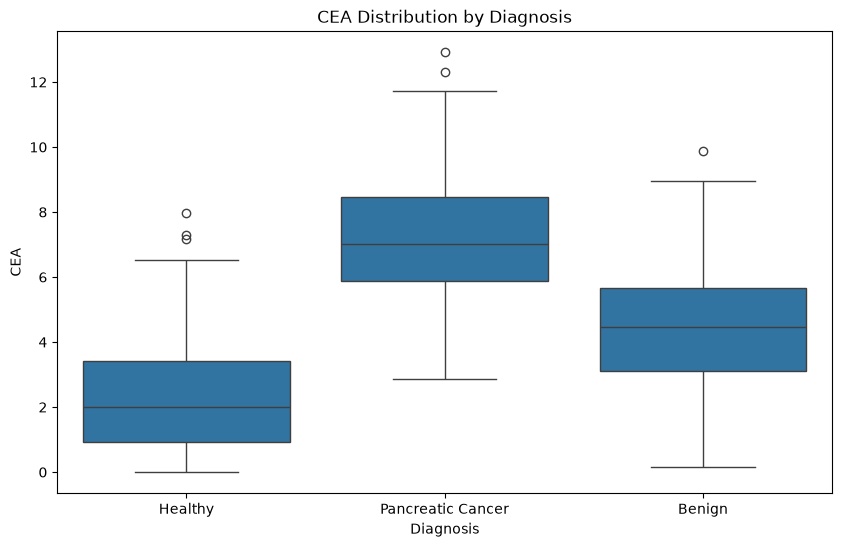

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="diagnosis_label",
    y="CEA"
)

plt.title("CEA Distribution by Diagnosis")

plt.xlabel("Diagnosis")
plt.ylabel("CEA")

plt.show()

In [19]:
df.groupby("diagnosis_label")["CEA"].describe()

,count,mean,std,min,25%,50%,75%,max
diagnosis_label,,,,,,,,
Benign,214.0,4.413200,1.919894,0.1548,3.115050,4.4496,5.653450,9.8693
Healthy,256.0,2.271086,1.591674,0.0021,0.938025,2.0093,3.417825,7.9636
Pancreatic Cancer,130.0,7.207424,2.042615,2.8654,5.877300,7.0111,8.447775,12.9217


### Findings

CEA demonstrates a clear relationship with diagnosis status.
Healthy individuals exhibit the lowest CEA concentrations, benign cases occupy an intermediate range, and pancreatic cancer patients show the highest values.Although some overlap exists between groups, the overall separation suggests that CEA may be an important predictor for pancreatic cancer detection.

### Biomarker Correlation Analysis

The relationships between clinical biomarkers are examined to identify potential associations and patterns within the dataset.

In [20]:
biomarkers = [
    "plasma_C",
    "creatinine",
    "LYVE1",
    "REG1B",
    "TFF1",
    "REG1A",
    "CA19_9",
    "CEA",
    "bilirubin",
    "glucose",
    "urine_volume",
    "urine_pH"
]

corr = df[biomarkers].corr()


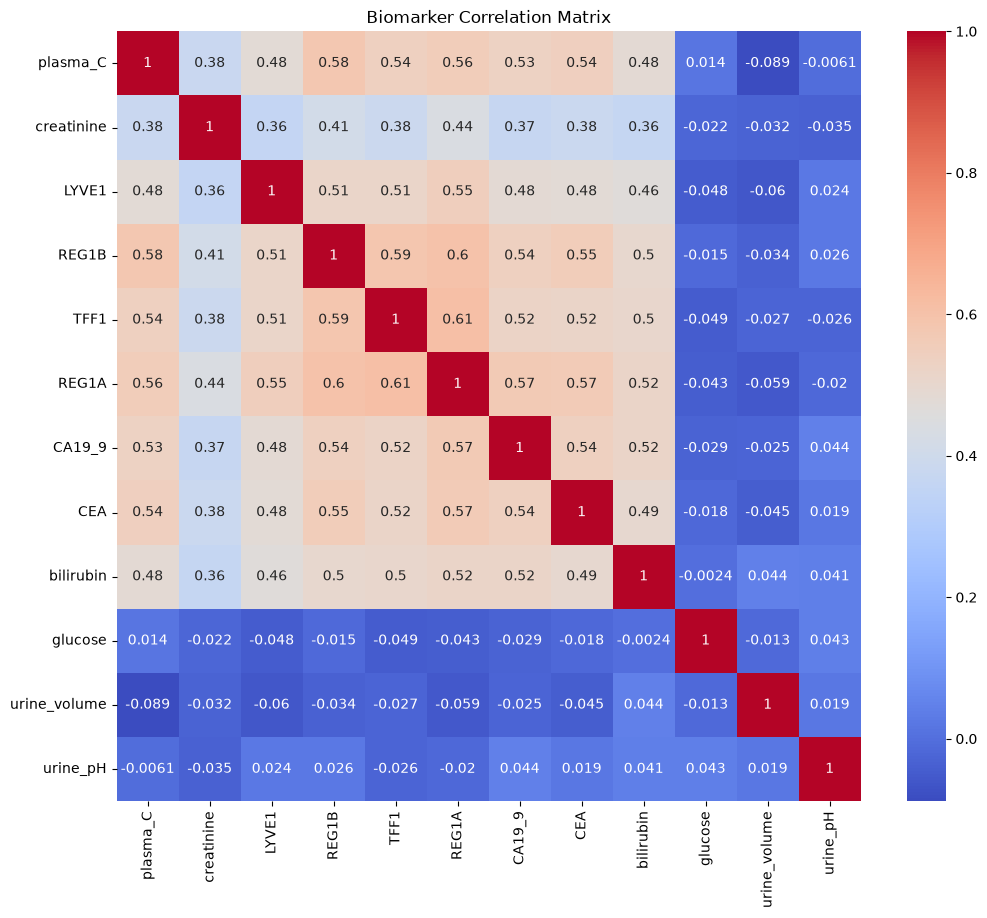

In [21]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Biomarker Correlation Matrix")

plt.show()

### Findings

Most biomarker variables exhibit moderate positive correlations with one another, particularly REG1A, REG1B, TFF1, CA19-9 and CEA.
These relationships suggest that several biomarkers may capture related biological processes associated with pancreatic disease.
In contrast, glucose, urine volume and urine pH show very weak correlations with the remaining biomarkers, indicating that they may provide complementary information.

### Biomarker Differences Across Diagnosis Groups

The average biomarker values are compared across diagnosis categories to identify variables that show the strongest separation between healthy individuals, benign conditions and pancreatic cancer cases.

In [22]:
biomarkers = [
    "plasma_C",
    "creatinine",
    "LYVE1",
    "REG1B",
    "TFF1",
    "REG1A",
    "CA19_9",
    "CEA",
    "bilirubin",
    "glucose",
    "urine_volume",
    "urine_pH"
]

group_means = (
    df.groupby("diagnosis_label")[biomarkers]
      .mean()
)

group_means.T

diagnosis_label,Benign,Healthy,Pancreatic Cancer
plasma_C,13.921686,8.854843,20.156370
creatinine,1.100114,0.894045,1.281437
LYVE1,1.000959,0.570920,1.490857
REG1B,142.413437,71.965951,214.472372
TFF1,156.276733,84.530452,260.924057
REG1A,701.796421,618.345539,759.457054
CA19_9,166.550528,110.116177,403.487055
CEA,4.413200,2.271086,7.207424
bilirubin,1.542818,0.843269,2.421309
glucose,101.953224,99.651875,97.793846


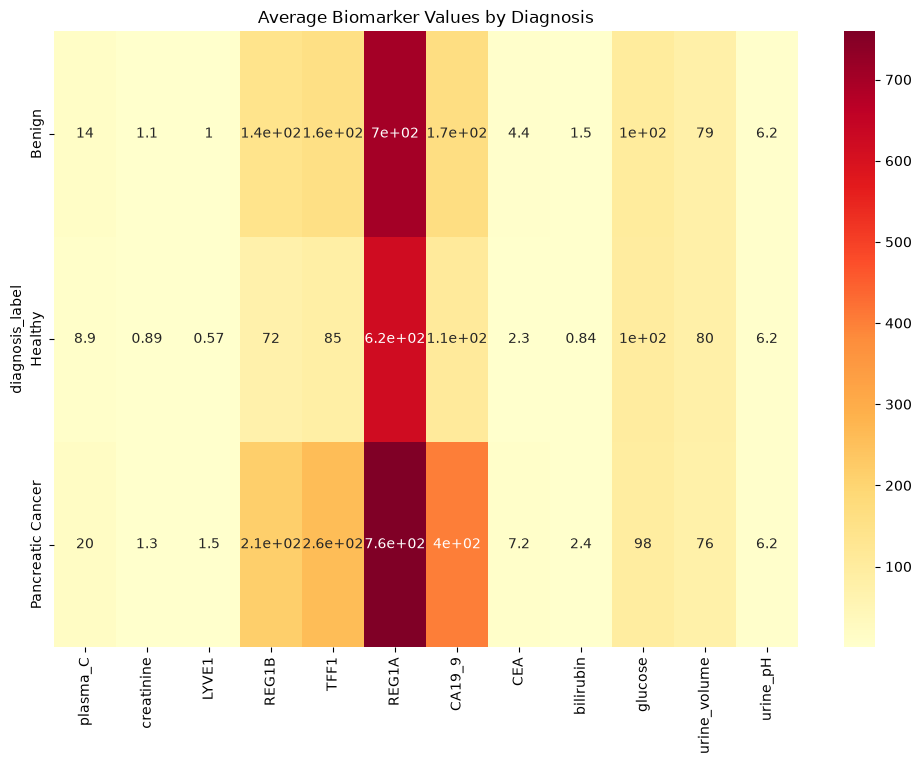

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    group_means,
    annot=True,
    cmap="YlOrRd"
)

plt.title("Average Biomarker Values by Diagnosis")

plt.show()

### Findings

Several biomarkers show substantial differences across diagnosis groups.
CA19-9, CEA, REG1A, REG1B and TFF1 consistently exhibit higher values among patients diagnosed with pancreatic cancer compared to healthy individuals and benign cases.
In contrast, variables such as glucose, urine volume and urine pH display only minor differences between groups, suggesting a weaker relationship with diagnosis status.

In [31]:
diagnosis_numeric = {
    "Healthy": 0,
    "Benign": 1,
    "Pancreatic Cancer": 2
}

df["diagnosis_numeric"] = (
    df["diagnosis_label"]
    .map(diagnosis_numeric)
)

corr_target = (
    df[
        biomarkers + ["diagnosis_numeric"]
    ]
    .corr()
)

corr_target[
    ["diagnosis_numeric"]
].sort_values(
    by="diagnosis_numeric",
    ascending=False
)

,diagnosis_numeric
diagnosis_numeric,1.000000
REG1A,0.800120
REG1B,0.768814
TFF1,0.728123
plasma_C,0.727980
CEA,0.718659
CA19_9,0.695658
bilirubin,0.676452
LYVE1,0.674863
creatinine,0.530452


### Findings

Several biomarkers exhibit strong positive relationships with diagnosis severity.
REG1A, REG1B, TFF1, plasma_C, CEA and CA19-9 show the strongest associations, consistently increasing from healthy patients to benign cases and pancreatic cancer patients.
In contrast, glucose, urine volume and urine pH display little relationship with diagnosis status, suggesting that they may provide limited discriminatory power.

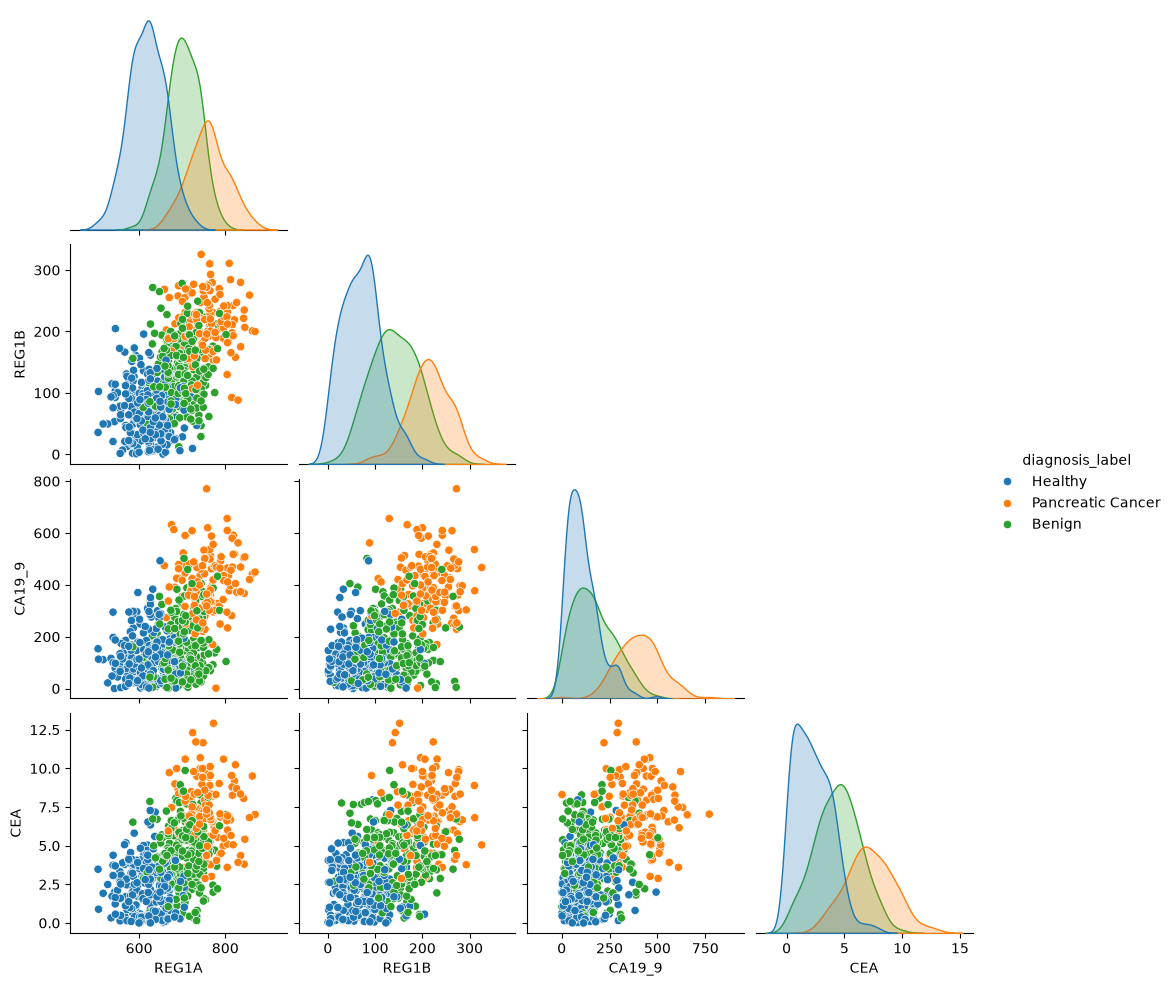

In [32]:
top_biomarkers = [
    "REG1A",
    "REG1B",
    "CA19_9",
    "CEA"
]

sns.pairplot(
    df,
    vars=top_biomarkers,
    hue="diagnosis_label",
    corner=True
)

plt.show()

### Findings

The pairwise biomarker analysis reveals visible separation between diagnosis groups.
Patients diagnosed with pancreatic cancer tend to exhibit higher REG1A, REG1B, CA19-9 and CEA values than healthy individuals and benign cases.
The strongest separation appears in combinations involving CA19-9 and CEA, where pancreatic cancer cases are concentrated in regions associated with elevated biomarker levels.
Although some overlap remains between classes, the observed clustering suggests that these biomarkers contain substantial discriminatory information and may support effective machine learning classification.

## Key Exploratory Findings

The exploratory analysis identified several biomarkers strongly associated with pancreatic cancer diagnosis.
CA19-9, CEA, REG1A, REG1B and TFF1 consistently exhibited higher values among pancreatic cancer patients compared to healthy individuals and benign cases.
Multiple biomarkers showed moderate positive correlations with one another, suggesting the existence of related biological mechanisms. However, sufficient variation remains to justify their inclusion in predictive modelling.
The visual analysis revealed meaningful separation between diagnosis groups, indicating strong potential for machine learning classification.